# Atividade: GANs

Neste notebook, você irá **preparar seu próprio dataset** e **treinar uma DCGAN utilizando a distância de Wasserstein**.
O objetivo é gerar imagens sintéticas a partir de ruído, aprendendo a distribuição dos dados reais.

O treinamento será realizado com um **Gerador** e um **Crítico** (substituindo o discriminador tradicional), aplicando **gradient clipping** para garantir a restrição de Lipschitz exigida pela métrica de Wasserstein.

Ao final, o modelo deverá ser capaz de **produzir imagens realistas** a partir de vetores aleatórios.

## Preparando os dados

Para esta atividade, será necessário baixar ou montar um dataset de imagens de um domínio específico (por exemplo, rostos, paisagens, objetos, etc.). Você pode utilizar datasets públicos como LFW e CelebA ou criar o seu próprio conjunto de imagens armazenadas em uma pasta local.

### Coleta de Imagens

Caso opte por montar seu próprio dataset, você pode utilizar a biblioteca iCrawler para baixar imagens automaticamente a partir de buscadores (como Google, Bing ou Baidu), fornecendo uma lista de termos relacionados ao domínio desejado.

In [2]:
pip install icrawler

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.0 MB 2.1 MB/s eta 0:00:02
   ---------- ----------------------------- 1.0/4.0 MB 2.4 MB/s eta 0:00:02
   --------------- ------------------------ 1.6/4.0 MB 2.1 MB/s eta 0:00:02
   -------------------- ------------------- 2.1/4.0 MB 2.2 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.0 MB 2.2 MB/s eta 0:00:01
   -------------------------- ------------- 2.6/4.0 MB 1.9 MB/s eta 0:00:01
   ------------------------------- -------- 3.1/4.0 MB 2.0 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.0 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------  3.9/4.0 MB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 1.9 MB/s  0:00:02

   ---------------------------------------- 0/3 [lxml]
   ---------------------------------------- 0/3 [

In [4]:
import os
from icrawler.builtin import GoogleImageCrawler, BingImageCrawler

def download_images(keyword, folder, n_total=100):
    os.makedirs(folder, exist_ok=True)
    downloaded = len(os.listdir(folder))
    remaining = n_total - downloaded

    while downloaded < n_total:
        crawler = BingImageCrawler(storage={'root_dir': folder})
        crawler.crawl(keyword=keyword, max_num=remaining, file_idx_offset=downloaded)
        downloaded = len(os.listdir(folder))
        remaining = n_total - downloaded
        print(f"Downloaded {downloaded}/{n_total}")

    print("Download complete!")

In [9]:
download_images("wolf", f"data/wolf_images", n_total=200)

2025-12-05 15:15:38,399 - INFO - icrawler.crawler - start crawling...
2025-12-05 15:15:38,400 - INFO - icrawler.crawler - starting 1 feeder threads...
2025-12-05 15:15:38,402 - INFO - icrawler.crawler - starting 1 parser threads...
2025-12-05 15:15:38,404 - INFO - icrawler.crawler - starting 1 downloader threads...
2025-12-05 15:15:39,194 - INFO - parser - parsing result page https://www.bing.com/images/async?q=wolf&first=0
2025-12-05 15:15:40,955 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:15:41,510 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:15:41,626 - INFO - downloader - image #1	https://www.warrenphotographic.co.uk/photography/bigs/03981-Grey-Wolf.jpg
2025-12-05 15:15:41,992 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:15:42,392 - ERROR - downloader - Response status code 404, file https://upload.wikimedia.org/wikipedia/commons/thumb/7/70/Front_view_of_a_restin

Downloaded 19/200


2025-12-05 15:16:15,223 - INFO - parser - parsing result page https://www.bing.com/images/async?q=wolf&first=0
2025-12-05 15:16:16,026 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:16:16,585 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:16:17,051 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:16:18,272 - INFO - downloader - image #1	https://www.warrenphotographic.co.uk/photography/bigs/03981-Grey-Wolf.jpg
2025-12-05 15:16:19,142 - ERROR - downloader - Response status code 404, file https://upload.wikimedia.org/wikipedia/commons/thumb/7/70/Front_view_of_a_resting_Canis_lupus_ssp.jpg
2025-12-05 15:16:19,922 - INFO - downloader - image #2	https://wwfint.awsassets.panda.org/img/w01049_dsc2169_20090911_8100a_wolf__c__ralph_frank_wwf_546040.jpg
2025-12-05 15:16:20,816 - INFO - downloader - image #3	https://png.pngtree.com/background/20230615/original/pngtree-close-up-of-a-gray-

Downloaded 40/200


2025-12-05 15:16:46,072 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:16:46,243 - INFO - parser - parsing result page https://www.bing.com/images/async?q=wolf&first=0
2025-12-05 15:16:46,647 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:16:47,115 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:16:48,024 - INFO - downloader - image #1	https://www.warrenphotographic.co.uk/photography/bigs/03981-Grey-Wolf.jpg
2025-12-05 15:16:48,574 - ERROR - downloader - Response status code 404, file https://upload.wikimedia.org/wikipedia/commons/thumb/7/70/Front_view_of_a_resting_Canis_lupus_ssp.jpg
2025-12-05 15:16:49,098 - INFO - downloader - image #2	https://wwfint.awsassets.panda.org/img/w01049_dsc2169_20090911_8100a_wolf__c__ralph_frank_wwf_546040.jpg
2025-12-05 15:16:50,070 - INFO - downloader - image #3	https://png.pngtree.com/background/20230615/original/pngtree-close-up-of-a-gray-

...

2025-12-05 15:19:31,908 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:19:32,420 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:19:32,448 - INFO - parser - parsing result page https://www.bing.com/images/async?q=wolf&first=0
2025-12-05 15:19:34,992 - INFO - downloader - image #1	https://www.warrenphotographic.co.uk/photography/bigs/03981-Grey-Wolf.jpg
2025-12-05 15:19:35,567 - ERROR - downloader - Response status code 404, file https://upload.wikimedia.org/wikipedia/commons/thumb/7/70/Front_view_of_a_resting_Canis_lupus_ssp.jpg
2025-12-05 15:19:36,058 - INFO - downloader - image #2	https://wwfint.awsassets.panda.org/img/w01049_dsc2169_20090911_8100a_wolf__c__ralph_frank_wwf_546040.jpg
2025-12-05 15:19:36,353 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:19:36,636 - INFO - downloader - image #3	https://png.pngtree.com/background/20230615/original/pngtree-close-up-of-a-gray-

Downloaded 185/200


2025-12-05 15:19:59,803 - INFO - parser - parsing result page https://www.bing.com/images/async?q=wolf&first=0
2025-12-05 15:20:01,398 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:01,957 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:02,466 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:04,416 - INFO - downloader - image #1	https://www.warrenphotographic.co.uk/photography/bigs/03981-Grey-Wolf.jpg
2025-12-05 15:20:05,347 - ERROR - downloader - Response status code 404, file https://upload.wikimedia.org/wikipedia/commons/thumb/7/70/Front_view_of_a_resting_Canis_lupus_ssp.jpg
2025-12-05 15:20:06,193 - INFO - downloader - image #2	https://wwfint.awsassets.panda.org/img/w01049_dsc2169_20090911_8100a_wolf__c__ralph_frank_wwf_546040.jpg
2025-12-05 15:20:06,406 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:06,966 - INFO - downloa

Downloaded 200/200
Download complete!


2025-12-05 15:20:31,450 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:32,009 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:32,523 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:36,452 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:37,013 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:37,524 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:41,468 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:42,029 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:42,539 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:46,485 - INFO - downloader - downloader-001 is waiting for new download tasks
2025-12-05 15:20:47,044 - INFO - downloader - down

### Implementação do Dataset

Com as imagens já disponíveis, implemente uma **classe de Dataset personalizada** para o PyTorch. Ela deve herdar de `Dataset` e retornar, em cada amostra, a imagem processada pelos **transforms** definidos anteriormente.

O Dataset deve:

* Ler as imagens a partir de uma pasta.
* Converter as imagens para **tensor normalizado** (ex.: valores entre -1 e 1).

In [2]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class ImageDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.images = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

### Carregamento

Carregue os dados a partir do seu dataset de imagens e aplique os transforms necessários. Caso o dataset seja pequeno, recomenda-se o uso de data augmentation (como flips horizontais, jitter de cor ou pequenas rotações) para aumentar a diversidade das amostras e melhorar a estabilidade do treinamento adversarial. Em seguida, defina um batch size adequado e instancie um DataLoader.

In [28]:
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((64, 64)),
    # Caso tenha poucas imagens, adicione data augmentation aqui
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = ImageDataset("data/wolf_images", transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)

In [29]:
imgs = next(iter(train_loader))
print("Shape do batch:", imgs.shape)

Shape do batch: torch.Size([64, 3, 64, 64])


## Definição dos Modelos

Para este exercício, deverão ser utilizadas DCGANs com distância de Wasserstein. Nesta seção, defina a arquitetura dos modelos Gerador e Crítico, implementando o treinamento adversarial baseado na métrica de Wasserstein.

### Gerador

O Gerador seguirá a arquitetura típica de uma DCGAN, produzindo amostras sintéticas a partir de vetores de ruído, enquanto o Crítico avaliará a distância entre as distribuições reais e geradas.

In [21]:
import torch
from torch import nn
from torchinfo import summary

In [50]:
class Generator(nn.Module):
    def __init__(self, latent_dim, img_channels, features_g):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.net(input)

In [51]:
summary(Generator(100, 3, 64), input_size=(64, 100, 1, 1))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [64, 3, 64, 64]           --
├─Sequential: 1-1                        [64, 3, 64, 64]           --
│    └─ConvTranspose2d: 2-1              [64, 512, 4, 4]           819,200
│    └─BatchNorm2d: 2-2                  [64, 512, 4, 4]           1,024
│    └─ReLU: 2-3                         [64, 512, 4, 4]           --
│    └─ConvTranspose2d: 2-4              [64, 256, 8, 8]           2,097,152
│    └─BatchNorm2d: 2-5                  [64, 256, 8, 8]           512
│    └─ReLU: 2-6                         [64, 256, 8, 8]           --
│    └─ConvTranspose2d: 2-7              [64, 128, 16, 16]         524,288
│    └─BatchNorm2d: 2-8                  [64, 128, 16, 16]         256
│    └─ReLU: 2-9                         [64, 128, 16, 16]         --
│    └─ConvTranspose2d: 2-10             [64, 64, 32, 32]          131,072
│    └─BatchNorm2d: 2-11                 [64, 64, 32, 32] 

### Crítico

O Crítico (substituindo o discriminador tradicional) deve utilizar gradient clipping para garantir o cumprimento da restrição de Lipschitz, condição essencial para a estabilidade da função de custo de Wasserstein.

In [58]:
class Critic(nn.Module):
    def __init__(self, img_channels, features_d):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d, features_d * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 2, features_d * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 4, features_d * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
        )

    def forward(self, input):
        return self.net(input)

In [59]:
summary(Critic(3, 64), input_size=(64, 3, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
Critic                                   [64, 1, 1, 1]             --
├─Sequential: 1-1                        [64, 1, 1, 1]             --
│    └─Conv2d: 2-1                       [64, 64, 32, 32]          3,072
│    └─LeakyReLU: 2-2                    [64, 64, 32, 32]          --
│    └─Conv2d: 2-3                       [64, 128, 16, 16]         131,072
│    └─BatchNorm2d: 2-4                  [64, 128, 16, 16]         256
│    └─LeakyReLU: 2-5                    [64, 128, 16, 16]         --
│    └─Conv2d: 2-6                       [64, 256, 8, 8]           524,288
│    └─BatchNorm2d: 2-7                  [64, 256, 8, 8]           512
│    └─LeakyReLU: 2-8                    [64, 256, 8, 8]           --
│    └─Conv2d: 2-9                       [64, 512, 4, 4]           2,097,152
│    └─BatchNorm2d: 2-10                 [64, 512, 4, 4]           1,024
│    └─LeakyReLU: 2-11                   [64, 512, 4, 4]    

## Treinamento

Com o **Gerador** e o **Crítico** definidos, e os dados devidamente carregados, inicie o treinamento.

Durante o processo:

* Atualize o **Crítico** várias vezes para cada atualização do **Gerador**, garantindo uma estimativa mais precisa da distância de Wasserstein.
* Aplique **gradient clipping** nos parâmetros do Crítico após cada atualização, mantendo a restrição de **Lipschitz**.
* Utilize **losses baseadas na métrica de Wasserstein**.

Ao longo do treinamento, **visualize amostras geradas** a cada determinado número de épocas, observando a evolução da qualidade das imagens produzidas pelo Gerador.

In [61]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [68]:
from torch.optim import Adam, RMSprop

In [76]:
from torch.nn.utils import clip_grad_norm_

[0/499] Loss C: -44.3775 | Loss G: 22.2742


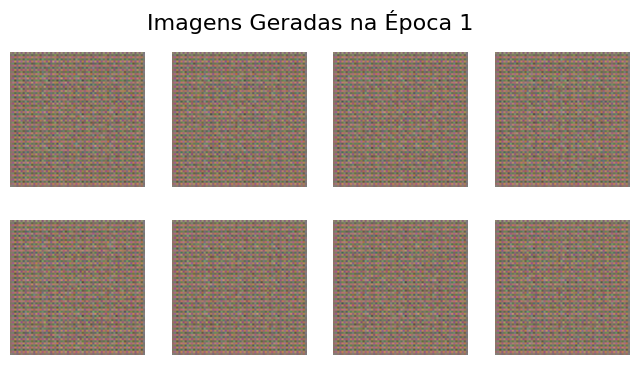

[50/499] Loss C: -608.5393 | Loss G: 297.1451


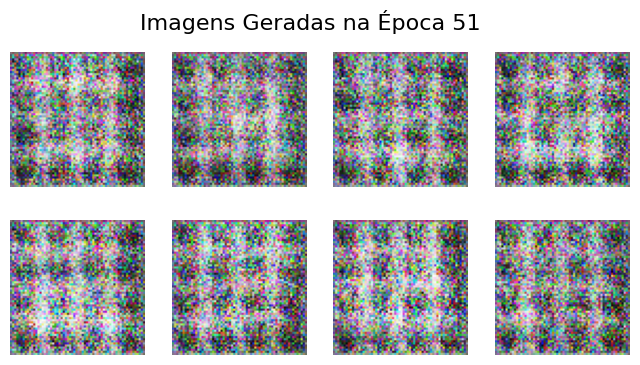

[100/499] Loss C: -1067.7975 | Loss G: 522.3394


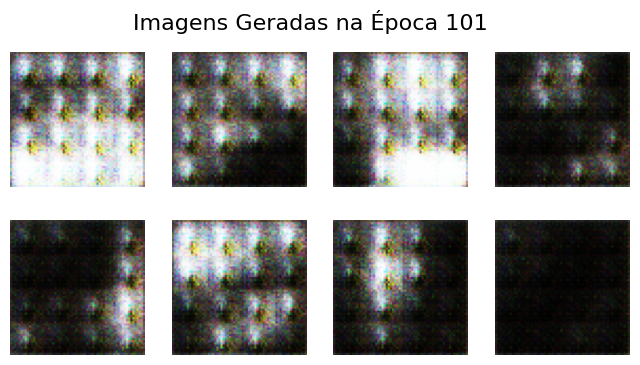

[150/499] Loss C: -1748.3031 | Loss G: 852.4533


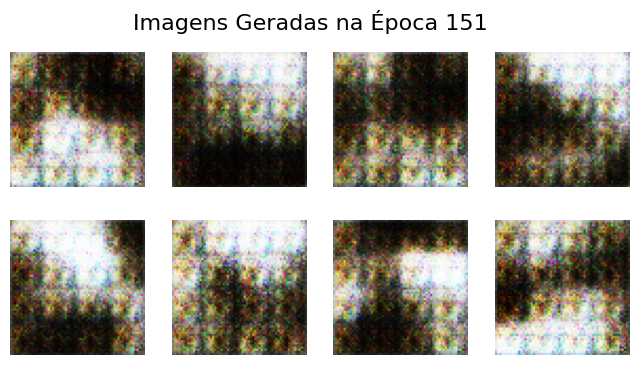

[200/499] Loss C: -2438.8313 | Loss G: 1187.2117


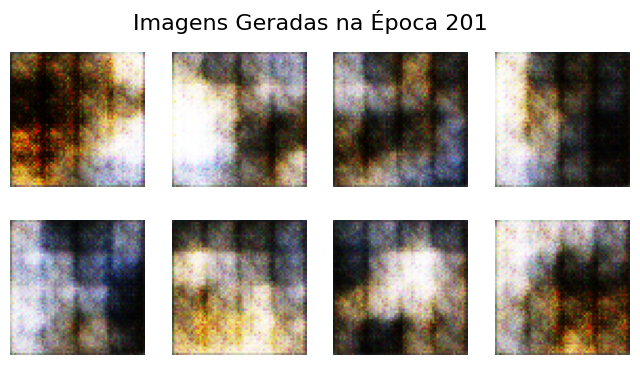

[250/499] Loss C: -3311.9536 | Loss G: 1608.5807


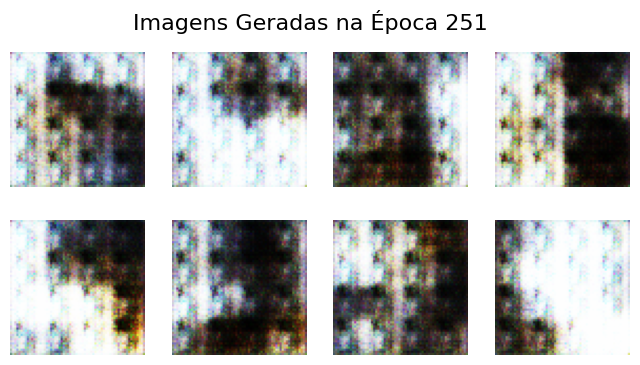

[300/499] Loss C: -4192.9998 | Loss G: 2032.0781


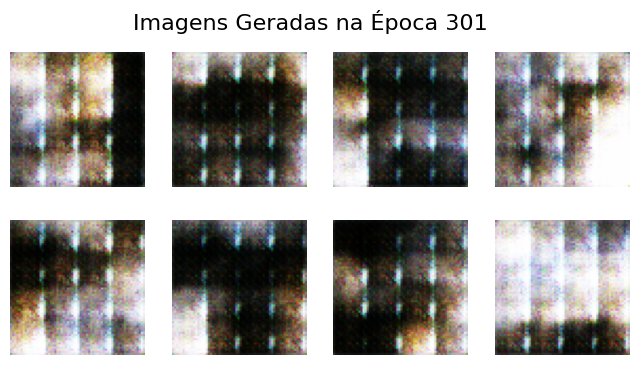

[350/499] Loss C: -5199.5975 | Loss G: 2514.1901


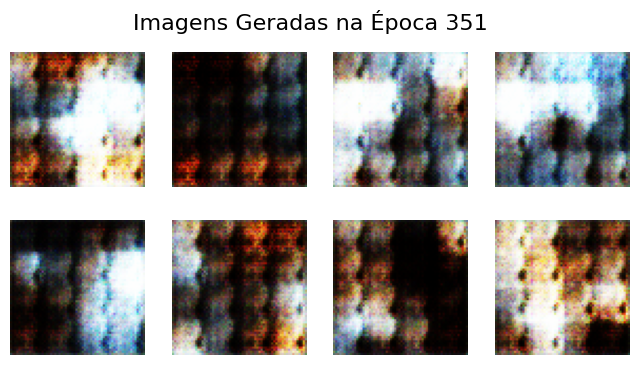

[400/499] Loss C: -6238.5782 | Loss G: 3013.2738


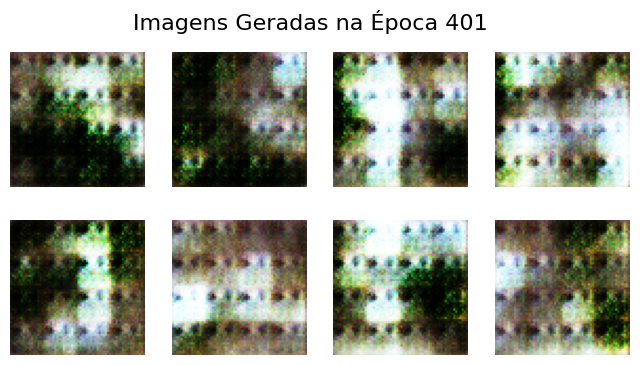

[450/499] Loss C: -7341.8119 | Loss G: 3543.7950


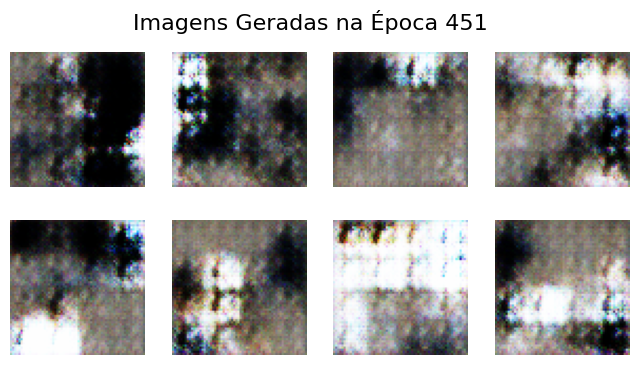

[499/499] Loss C: -8558.1646 | Loss G: 4128.7307


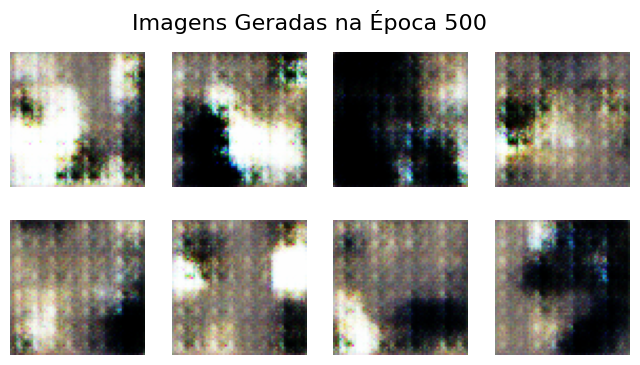

In [86]:
num_epochs = 500
n_critic = 5 # Número de vezes que o crítico é treinado por iteração do gerador
clip_value = 0.01 # Valor para o weight clipping
plot_interval = 50

g = Generator(100, 3, 64).to(device)
c = Critic(3, 64).to(device)

lr = 0.00005

optimizer_g = RMSprop(g.parameters(), lr=lr)
optimizer_c = RMSprop(c.parameters(), lr=lr)

g_losses = []
c_losses = []

for epoch in range(num_epochs):
    g.train()
    c.train()
    
    g_running_loss = 0.0
    c_running_loss = 0.0

    for i, (real_imgs) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # --- Treinamento do Crítico (n_critic iterações) ---
        for _ in range(n_critic):
            optimizer_c.zero_grad()
            
            noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_imgs = g(noise).detach()
            
            critic_real = c(real_imgs).view(-1).mean()
            critic_fake = c(fake_imgs).view(-1).mean()
            
            # A perda do crítico é -(score_real - score_fake)
            loss_c = -(critic_real - critic_fake)
            loss_c.backward()

            clip_grad_norm_(c.parameters(), 1.0)
            
            optimizer_c.step()
        
        c_running_loss += loss_c.item()
        
        # --- Treinamento do Gerador ---
        optimizer_g.zero_grad()
        
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        gen_imgs = g(noise)
        output = c(gen_imgs).view(-1).mean()
        
        # A perda do gerador é -score_fake
        loss_g = -output
        loss_g.backward()
        optimizer_g.step()

        g_running_loss += loss_g.item()

    g_epoch_loss = g_running_loss / len(train_loader)
    c_epoch_loss = c_running_loss / len(train_loader)
    
    g_losses.append(g_epoch_loss)
    c_losses.append(c_epoch_loss)

    if epoch % plot_interval == 0 or epoch == num_epochs - 1:
        print(f"[{epoch}/{num_epochs-1}] Loss C: {c_epoch_loss:.4f} | Loss G: {g_epoch_loss:.4f}")
        
        g.eval()
        with torch.no_grad():
            n_images = 8
            sample_noise = torch.randn(n_images, latent_dim, 1, 1, device=device)
            generated_imgs = g(sample_noise).detach().cpu()

            fig, axs = plt.subplots(2, 4, figsize=(8, 4))
            fig.suptitle(f'Imagens Geradas na Época {epoch+1}', fontsize=16)
            for i in range(n_images):
                row = i // 4
                col = i % 4
                
                img = generated_imgs[i]           
                img = (img + 1) / 2               
                img = img.permute(1, 2, 0)        
            
                axs[row, col].imshow(img)
                axs[row, col].axis("off")
            plt.show()

## Inferência

Após o treinamento, utilize o **Gerador** para produzir novas imagens a partir de **vetores de ruído aleatório**.
Cada vetor servirá como ponto de partida no espaço latente, sendo transformado pelo modelo em uma amostra sintética do domínio aprendido.

Durante a inferência:

* Gere múltiplas imagens e visualize os resultados.
* Analise a **qualidade e diversidade** das amostras produzidas.

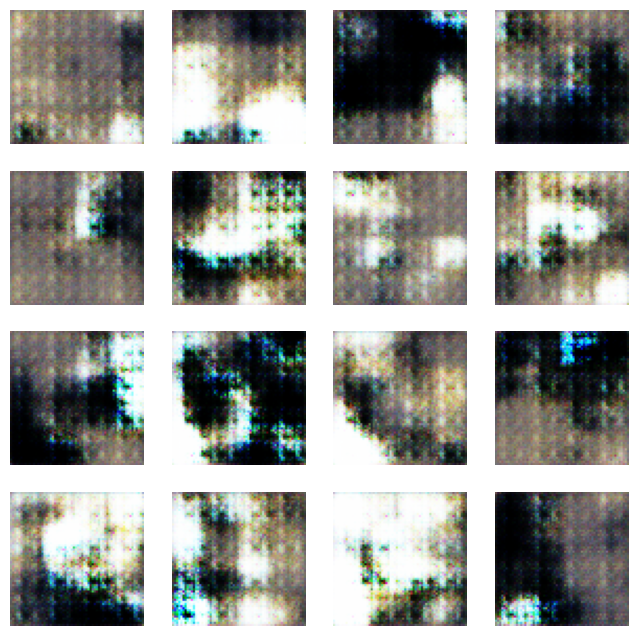

In [98]:
g.eval()

n_samples = 16
noise = torch.randn(n_samples, latent_dim, 1, 1, device=device)

with torch.no_grad():
    generated_imgs = g(noise)

    generated_imgs = (generated_imgs + 1) / 2
    
    n_rows = 4
    n_cols = 4
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(8,8))
    for i in range(n_samples):
        row = i // n_cols
        col = i % n_cols
        img = generated_imgs[i].permute(1,2,0).cpu().numpy()
        axs[row, col].imshow(img)
        axs[row, col].axis("off")
    plt.show()

### As imagens produzidas apresentam uma certa diversidade, porém a qualidade é tão baixa que não é possível identificar o que está sendo gerado.